## 创建项目文件夹

::: {.callout-tip}
### 提示词

- 在当前目录下新建如下文件夹-若已存在则忽略：
  - 'data_raw', 'data_clean' 两个文件夹，分别存放原始数据和清洗后的数据。
  - 'output' 文件夹，存放分析结果。
  - 'code' 文件夹，存放数据清洗和分析的代码。
- 添加必要的 Python 头部代码和注释，确保代码可读性和可维护性。
- 在代码中使用适当的函数和库（如 pandas、numpy 等）进行数据清洗和分析。
:::


In [1]:
import os

# Define the parent directory (one level up from current directory)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

# List of folders to create
folders = ['data_raw', 'data_clean', 'output', 'code']

# Create folders if they don't exist
for folder in folders:
    folder_path = os.path.join(parent_dir, folder)
    os.makedirs(folder_path, exist_ok=True)
    print(f"Folder '{folder}' {'already exists' if os.path.exists(folder_path) else 'created'} at: {folder_path}")

print("\nAll folders are ready.")

Folder 'data_raw' already exists at: g:\dsfin\Lecture\data_clean\data_raw
Folder 'data_clean' already exists at: g:\dsfin\Lecture\data_clean\data_clean
Folder 'output' already exists at: g:\dsfin\Lecture\data_clean\output
Folder 'code' already exists at: g:\dsfin\Lecture\data_clean\code

All folders are ready.


## 产生虚构数据

生成第三章「数据清洗」演示用的虚构数据集
执行后在 `../data_raw/` 文件夹生成以下文件：

- `BasicInf.csv`：包含公司基本信息，如股票代码、公司名称、所属行业和是否为国有企业。
- `FinRatio.csv`：包含公司财务比率信息，如杠杆率、公司规模、资产回报率和研发投入比例。
- `Announcement.csv`：包含公司公告文本信息，用于演示文本数据处理。

In [1]:
"""
create_sample_data.py
生成第三章「数据清洗」演示用的虚构数据集
执行后在 data_raw/ 文件夹生成以下文件：
  - BasicInf.csv
  - FinRatio.csv
  - Announcement.csv
"""

import pandas as pd
import os

#os.makedirs('../data_raw', exist_ok=True)


# ── BasicInf ──────────────────────────────────────────────
# 植入问题：stkcd 第二行为整数 2（格式不一致）
#           industry 第三行含前导空格（格式不一致）

basicinf = pd.DataFrame({
    'stkcd':      ['000001', 2,        '000063',  '600028', '600036'],
    'comp_name':  ['平安银行', '万科A', '中兴通讯', '中国石化', '招商银行'],
    'industry':   ['银行业',  '房地产业', ' 通信设备', '石油化工', '银行业'],
    'soe':        [0,          0,         0,          1,         0],
})

basicinf.to_csv('data_raw/BasicInf.csv', index=False, encoding='utf-8-sig')
print("BasicInf.csv 已生成，shape:", basicinf.shape)
print(basicinf.to_string(index=False))
print()


# ── FinRatio ──────────────────────────────────────────────
# 保留变量：Leverage, Size, ROA, RD（删去 CFlow, Cash_holding）
# 实际分析中会放入更多控制变量，这里为演示目的仅保留四个财务指标
#
# 植入问题：
#   - stkcd=2（格式不一致，与 BasicInf 呼应）
#   - 000001 同时含 report_type A 和 B（报表类型混入）
#   - Leverage=3.21（离群值）
#   - ROA=-0.18（离群值）
#   - Size='23.9'（数值存为字符串）
#   - RD 含缺失值（NaN）

finratio = pd.DataFrame({
    'stkcd': [
        '000001','000001','000001','000001',
        2, 2, 2, 2,
        '000063','000063',
    ],
    'year': [
        2022, 2022, 2023, 2023,
        2022, 2022, 2023, 2023,
        2022, 2023,
    ],
    'report_type': [
        'A','B','A','B',
        'A','B','A','B',
        'A','A',
    ],
    'Leverage': [
        0.89, 0.91, 0.88, 0.90,
        0.65, 0.67, 0.68, 0.69,
        0.52, 3.21,        # 3.21 为离群值
    ],
    'Size': [
        25.3, 25.1, 25.4, 25.2,
        24.1, 24.0, 24.2, 24.1,
        23.8, '23.9',      # '23.9' 为字符串类型
    ],
    'ROA': [
        0.012, 0.010, 0.013, 0.011,
        0.045, 0.043, 0.041, 0.040,
        0.038, -0.18,      # -0.18 为离群值
    ],
    'RD': [
        None, None, None, None,   # 银行业通常无研发支出披露
        0.008, 0.008, 0.009, 0.009,
        0.052, 0.048,
    ],
})

finratio.to_csv('data_raw/FinRatio.csv', index=False, encoding='utf-8-sig')
print("FinRatio.csv 已生成，shape:", finratio.shape)
print(finratio.to_string(index=False))
print()


# ── Announcement ─────────────────────────────────────────
# 每行为一条公告原文
# 植入问题：
#   - 前两行完全重复（同一条公告被爬取两次）
#   - 第三条与第一条同一公司同一年，但为另一笔贷款（多条记录合并铺垫）
#   - stkcd=2（格式不一致）
#   - 第三条公告表述方式与前两条有差异（体现非结构化特点）

announcement = pd.DataFrame({
    'stkcd': ['000001', '000001', '000001', 2,        '000063'],
    'year':  [2023,      2023,     2023,     2022,      2023],
    'text': [
        # 第一条（标准格式）
        '本公司于2023年6月1日，与建行深圳分行签署贷款协议，'
        '贷款金额为2亿元，期限3年，利率为年化4.2%。',

        # 第二条（与第一条完全重复，模拟重复爬取）
        '本公司于2023年6月1日，与建行深圳分行签署贷款协议，'
        '贷款金额为2亿元，期限3年，利率为年化4.2%。',

        # 第三条（同公司同年另一笔贷款，表述风格不同）
        # 差异点：金额用万元、银行写全称+总行直贷、
        #         利率写法为「执行利率」、期限写「60个月」
        '经董事会审议通过，本公司与中国工商银行股份有限公司总行'
        '于2023年8月15日签订《流动资金借款合同》，'
        '借款金额15,000万元，借款期限60个月，'
        '执行利率为年利率4.50%，资金用途为补充流动资金。',

        # 第四条（万科A，金额单位亿元，利率较低体现国有大行优势）
        '本公司于2022年3月10日与中国银行股份有限公司总行签署授信协议，'
        '授信额度5亿元，贷款期限3年，贷款年利率3.8%。',

        # 第五条（中兴通讯，农行地级分行，金额单位万元）
        '2023年11月20日，本公司与中国农业银行股份有限公司深圳宝安支行'
        '签订借款合同，金额人民币8,000万元，期限2年，'
        '年化利率4.60%，用于项目建设。',
    ],
})

announcement.to_csv('data_raw/Announcement.csv', index=False, encoding='utf-8-sig')
print("Announcement.csv 已生成，shape:", announcement.shape)
print(announcement.to_string(index=False))

BasicInf.csv 已生成，shape: (5, 4)
 stkcd comp_name industry  soe
000001      平安银行      银行业    0
     2       万科A     房地产业    0
000063      中兴通讯     通信设备    0
600028      中国石化     石油化工    1
600036      招商银行      银行业    0

FinRatio.csv 已生成，shape: (10, 7)
 stkcd  year report_type  Leverage  Size    ROA    RD
000001  2022           A      0.89  25.3  0.012   NaN
000001  2022           B      0.91  25.1  0.010   NaN
000001  2023           A      0.88  25.4  0.013   NaN
000001  2023           B      0.90  25.2  0.011   NaN
     2  2022           A      0.65  24.1  0.045 0.008
     2  2022           B      0.67  24.0  0.043 0.008
     2  2023           A      0.68  24.2  0.041 0.009
     2  2023           B      0.69  24.1  0.040 0.009
000063  2022           A      0.52  23.8  0.038 0.052
000063  2023           A      3.21  23.9 -0.180 0.048

Announcement.csv 已生成，shape: (5, 3)
 stkcd  year                                                                                                text
000001 

## 样本选择偏差演示数据 

> 缺失值-非随机缺失-样本选择偏误

In [5]:
"""
## 样本选择偏差演示数据

将此 cell 追加至 create_sample_data.ipynb

研究问题：上市公司贷款利率（Rate）的影响因素
- y  = 贷款利率（%）
- x1 = Leverage（总负债/总资产）
- x2 = Size（ln 总资产）
- 控制变量：soe（是否国企）

【缺失机制——样本选择偏差的核心】
  规模较小的公司（Size < 24）往往缺乏公开债券/银行贷款记录，
  贷款利率无法从公告中获取（Rate = NaN）。
  → 缺失不随机：缺失组 Size 显著偏低（p < 0.05），Leverage 偏高
  → 若直接用 Rate 非缺失的样本回归，Size 的负向效应会被高估，
    Leverage 的正向效应也会被低估

【后续方法铺垫】
  第七章将介绍 Heckman 两步法（先对缺失建模，再纠正主回归）
  和倾向得分匹配（PSM）来处理此类问题。
"""

# ── 0. 准备 ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import os

os.makedirs('./fig', exist_ok=True)

# 自动检测并设置中文字体（兼容 Windows / macOS / Linux）
import matplotlib.font_manager as fm
_cjk_candidates = [
    'Microsoft YaHei', 'SimHei', 'PingFang SC',
    'Hiragino Sans GB', 'WenQuanYi Zen Hei', 'Noto Sans CJK SC',
]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _cjk_candidates if f in _available), None)
if _font:
    plt.rcParams['font.family'] = _font
plt.rcParams['axes.unicode_minus'] = False


# ── 1. 构造 mini 数据集 ────────────────────────────────────
#
# 观测值 1-6：贷款利率已知（Rate 有值）
#   平安银行、万科A、中兴通讯、中国石化、招商银行、格力电器
#   → 规模较大（Size 23.5–26.2），信息披露充分
#
# 观测值 7-10：贷款利率缺失（Rate = None）
#   宁德时代、东方财富、三一重工、比亚迪
#   → 规模偏小（Size 22.8–23.9），贷款信息未在公告中披露
#   → Leverage 偏高（0.68–0.75）：小公司更依赖间接融资，但信披不足
#   → 均为民企（soe = 0）：披露动力相对较弱

sample_selection = pd.DataFrame({
    'id':       range(1, 11),
    'comp':     ['平安银行', '万科A',   '中兴通讯', '中国石化', '招商银行', '格力电器',
                 '宁德时代', '东方财富', '三一重工', '比亚迪'],
    'soe':      [0, 0, 0, 1, 0, 0,   0, 0, 0, 0],
    'Leverage': [0.89, 0.65, 0.52, 0.58, 0.88, 0.44,
                 0.72, 0.68, 0.75, 0.70],
    'Size':     [25.3, 24.1, 23.8, 26.2, 25.4, 23.5,
                 23.2, 22.8, 23.9, 23.4],
    'Rate':     [4.20, 3.85, 4.50, 3.60, 4.10, 4.75,
                 None, None, None, None],
})

sample_selection.to_csv('data_raw/SampleSelection.csv', index=False, encoding='utf-8-sig')
print("SampleSelection.csv 已生成，shape:", sample_selection.shape)
print(sample_selection.to_string(index=False))


# ── 2. 分组描述统计：直观确认缺失非随机 ─────────────────────
obs  = sample_selection[sample_selection['Rate'].notna()].copy()   # y 已知（n=6）
miss = sample_selection[sample_selection['Rate'].isna()].copy()    # y 缺失（n=4）

print("\n" + "=" * 60)
print("表 3-X  按 Rate 缺失状态分组的描述统计")
print("=" * 60)
print(f"{'变量':<14}  {'y 已知（n=6）':>14}  {'y 缺失（n=4）':>14}  {'差异':>8}")
print("-" * 60)

var_map = {'Leverage': '杠杆率', 'Size': '规模（ln）', 'soe': '国企占比'}
for var, cn in var_map.items():
    v_obs  = obs[var].mean()
    v_miss = miss[var].mean()
    diff   = v_miss - v_obs
    print(f"{cn:<14}  {v_obs:>14.3f}  {v_miss:>14.3f}  {diff:>+8.3f}")

print()
print("t 检验（H₀: 两组均值相等）")
for var, cn in {'Leverage': '杠杆率', 'Size': '规模'}.items():
    t, p = stats.ttest_ind(obs[var], miss[var])
    sig = '**' if p < 0.05 else ('†' if p < 0.10 else '')
    print(f"  {cn}: t = {t:+.2f}, p = {p:.3f} {sig}")
print("  注：† p<0.10, * p<0.05，样本量极小（n=10），仅作方向性参考")


SampleSelection.csv 已生成，shape: (10, 6)
 id comp  soe  Leverage  Size  Rate
  1 平安银行    0      0.89  25.3  4.20
  2  万科A    0      0.65  24.1  3.85
  3 中兴通讯    0      0.52  23.8  4.50
  4 中国石化    1      0.58  26.2  3.60
  5 招商银行    0      0.88  25.4  4.10
  6 格力电器    0      0.44  23.5  4.75
  7 宁德时代    0      0.72  23.2   NaN
  8 东方财富    0      0.68  22.8   NaN
  9 三一重工    0      0.75  23.9   NaN
 10  比亚迪    0      0.70  23.4   NaN

表 3-X  按 Rate 缺失状态分组的描述统计
变量                   y 已知（n=6）       y 缺失（n=4）        差异
------------------------------------------------------------
杠杆率                      0.660           0.712    +0.052
规模（ln）                  24.717          23.325    -1.392
国企占比                     0.167           0.000    -0.167

t 检验（H₀: 两组均值相等）
  杠杆率: t = -0.54, p = 0.601 
  规模: t = +2.42, p = 0.042 **
  注：† p<0.10, * p<0.05，样本量极小（n=10），仅作方向性参考



图片已保存至 ./fig/fig_data_clean_simulation_sample_selection.png


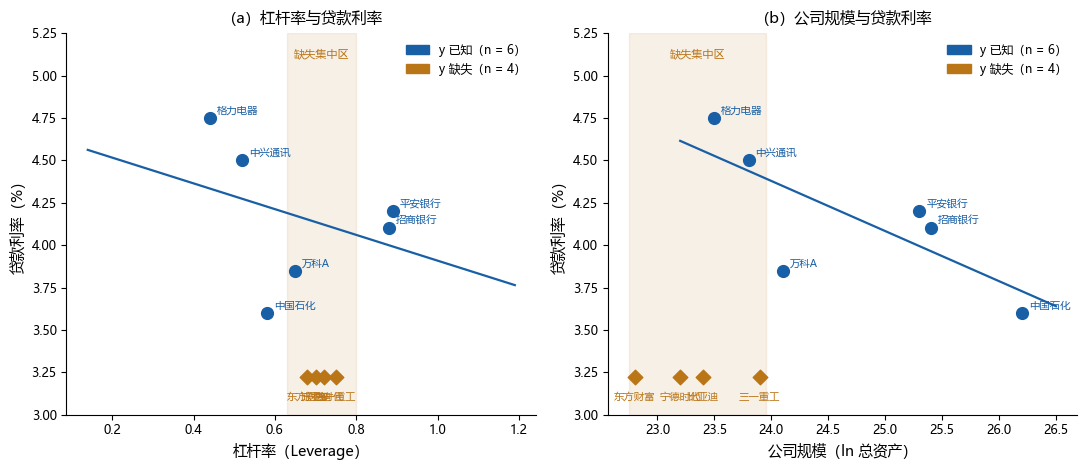

In [11]:


# ── 3. 散点图：可视化缺失组的 x 分布 ────────────────────────
BLUE   = '#185FA5'
ORANGE = '#BA7517'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
fig.patch.set_facecolor('white')

configs = [
    ('Leverage', '杠杆率（Leverage）',    '（a）杠杆率与贷款利率'),
    ('Size',     '公司规模（ln 总资产）', '（b）公司规模与贷款利率'),
]

for ax, (xvar, xlabel, title) in zip(axes, configs):

    # ① 缺失区域背景阴影
    xlo = miss[xvar].min() - 0.05
    xhi = miss[xvar].max() + 0.05
    ax.axvspan(xlo, xhi, alpha=0.10, color=ORANGE, zorder=0)

    # ② 已知组 OLS 拟合线
    xv = obs[xvar].values
    yv = obs['Rate'].values
    slope, intercept, *_ = stats.linregress(xv, yv)
    xfit = np.linspace(xv.min() - 0.3, xv.max() + 0.3, 200)
    ax.plot(xfit, intercept + slope * xfit, color=BLUE, lw=1.6, zorder=3)

    # ③ 已知组散点 + 公司名标注
    ax.scatter(xv, yv, color=BLUE, s=72, zorder=5)
    for _, row in obs.iterrows():
        ax.annotate(row['comp'],
                    xy=(row[xvar], row['Rate']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7.5, color=BLUE)

    # ④ 缺失组：底部菱形 + 公司名
    Y_MISS = 3.22
    for _, row in miss.iterrows():
        ax.scatter(row[xvar], Y_MISS, marker='D', color=ORANGE, s=55, zorder=5)
        ax.annotate(row['comp'],
                    xy=(row[xvar], Y_MISS),
                    xytext=(0, -16), textcoords='offset points',
                    ha='center', fontsize=7.5, color=ORANGE)

    # ⑤ 缺失区域文字标注
    ax.text((xlo + xhi) / 2, 5.10, '缺失集中区',
            ha='center', fontsize=8, color=ORANGE)

    # ⑥ 轴格式
    ax.set_xlabel(xlabel, fontsize=10.5)
    ax.set_ylabel('贷款利率（%）', fontsize=10.5)
    ax.set_ylim(3.0, 5.25)
    ax.tick_params(labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(title, fontsize=11, pad=8)

    # ⑦ 图例
    ax.legend(
        handles=[
            mpatches.Patch(color=BLUE,   label='y 已知（n = 6）'),
            mpatches.Patch(color=ORANGE, label='y 缺失（n = 4）'),
        ],
        fontsize=8.5, frameon=False, loc='upper right'
    )

# fig.suptitle(
#     '图 3-X  贷款利率的样本选择偏差：缺失公司的特征系统性不同于已知组',
#     fontsize=11, y=1.01
# )
plt.tight_layout()
fig.savefig('./fig/fig_data_clean_simulation_sample_selection.png',
            dpi=150, bbox_inches='tight', facecolor='white')

print("\n图片已保存至 ./fig/fig_data_clean_simulation_sample_selection.png")
plt.show()
plt.close()